In [71]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [72]:
df.shape

(920, 16)

In [73]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'country',
       'clinical_index'],
      dtype='str')

In [74]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,clinical_index
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000,865.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.545652,0.077769
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,0.498182,2.230653
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000,-6.020000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,-1.280000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000,0.310000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000,1.560000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000,8.680000


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             920 non-null    float64
 1   sex             920 non-null    float64
 2   cp              920 non-null    float64
 3   trestbps        861 non-null    float64
 4   chol            890 non-null    float64
 5   fbs             830 non-null    float64
 6   restecg         918 non-null    float64
 7   thalach         865 non-null    float64
 8   exang           865 non-null    float64
 9   oldpeak         858 non-null    float64
 10  slope           611 non-null    float64
 11  ca              309 non-null    float64
 12  thal            434 non-null    float64
 13  target          920 non-null    int64  
 14  country         920 non-null    str    
 15  clinical_index  865 non-null    float64
dtypes: float64(14), int64(1), str(1)
memory usage: 115.1 KB


## Variable Descriptions

In [76]:
df.isna().sum()

age                 0
sex                 0
cp                  0
trestbps           59
chol               30
fbs                90
restecg             2
thalach            55
exang              55
oldpeak            62
slope             309
ca                611
thal              486
target              0
country             0
clinical_index     55
dtype: int64

In [77]:
missing_values = df.isna().sum().sort_values(ascending=False)

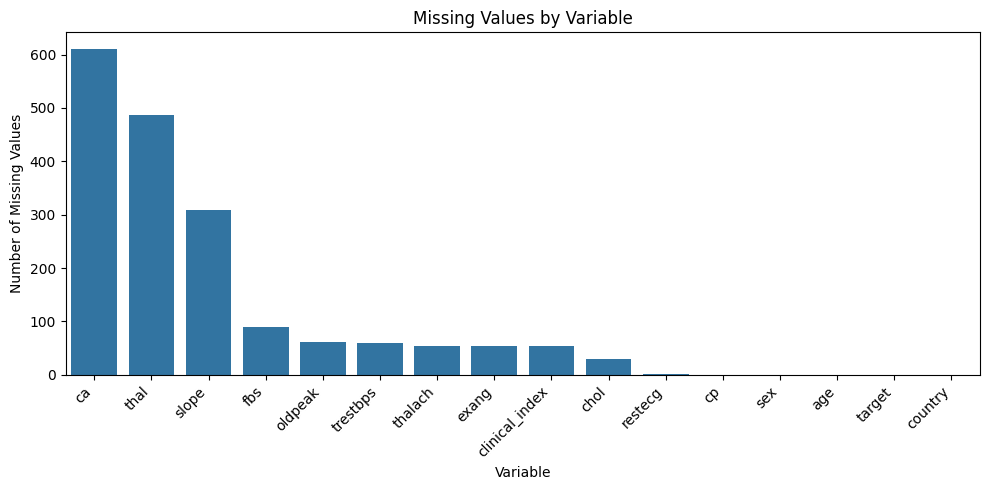

In [78]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [79]:
(df.isna().sum() / len(df)) * 100

age                0.000000
sex                0.000000
cp                 0.000000
trestbps           6.413043
chol               3.260870
fbs                9.782609
restecg            0.217391
thalach            5.978261
exang              5.978261
oldpeak            6.739130
slope             33.586957
ca                66.413043
thal              52.826087
target             0.000000
country            0.000000
clinical_index     5.978261
dtype: float64

In [80]:
df.groupby("country").apply(lambda x : x.isnull().sum())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,clinical_index
country,,,,,,,,,,,,,,,
Cleveland,0,0,0,0,0,0,0,0,0,0,0,4,2,0,0
Hungary,0,0,0,1,23,8,1,1,1,0,190,291,266,0,1
Switzerland,0,0,0,2,0,75,1,1,1,6,17,118,52,0,1
VA,0,0,0,56,7,7,0,53,53,56,102,198,166,0,53


In [81]:
df["cp"].unique()

array([2., 1., 3., 4.])

In [82]:
df["restecg"].unique()

array([ 2.,  0.,  1., nan])

In [83]:
df["slope"].unique()

array([nan,  2.,  1.,  3.])

In [84]:
df.groupby("country")["cp"].value_counts()

country      cp 
Cleveland    4.0    144
             3.0     86
             2.0     50
             1.0     23
Hungary      4.0    123
             2.0    106
             3.0     54
             1.0     11
Switzerland  4.0     98
             3.0     17
             1.0      4
             2.0      4
VA           4.0    131
             3.0     47
             2.0     14
             1.0      8
Name: count, dtype: int64

In [85]:
df.groupby("country")["restecg"].value_counts(dropna = False)

country      restecg
Cleveland    0.0        151
             2.0        148
             1.0          4
Hungary      0.0        235
             1.0         52
             2.0          6
             NaN          1
Switzerland  0.0         85
             1.0         30
             2.0          7
             NaN          1
VA           1.0         93
             0.0         80
             2.0         27
Name: count, dtype: int64

In [86]:
df.groupby("country")["slope"].value_counts(dropna = False)

country      slope
Cleveland    1.0      142
             2.0      140
             3.0       21
Hungary      NaN      190
             2.0       91
             1.0       12
             3.0        1
Switzerland  2.0       61
             1.0       33
             NaN       17
             3.0       12
VA           NaN      102
             2.0       53
             3.0       29
             1.0       16
Name: count, dtype: int64

In [87]:
df["target"].value_counts()

target
1    502
0    418
Name: count, dtype: int64

In [88]:
df["target"].value_counts(normalize=True)

target
1    0.545652
0    0.454348
Name: proportion, dtype: float64

In [89]:
pd.crosstab(df["country"], df["target"], normalize= True)

target,0,1
country,,
Cleveland,0.181522,0.147826
Hungary,0.197826,0.121739
Switzerland,0.018478,0.115217
VA,0.056522,0.160870


In [90]:
pd.crosstab(df["country"], df["target"], normalize= "index")

target,0,1
country,,
Cleveland,0.551155,0.448845
Hungary,0.619048,0.380952
Switzerland,0.138211,0.861789
VA,0.260000,0.740000


Disease prevalence differs substantially across regions, suggesting that the populations may not be fully homogeneous.

<Axes: xlabel='age', ylabel='Count'>

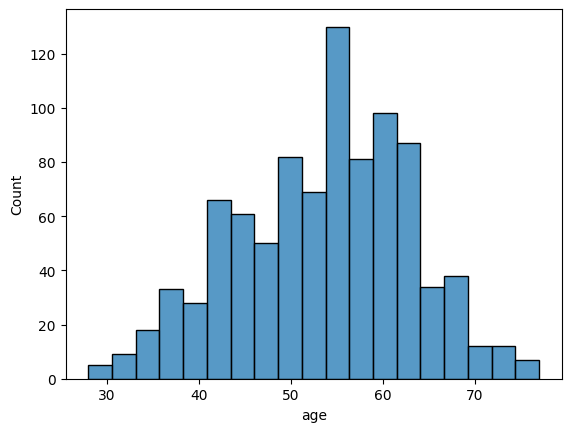

In [91]:
import seaborn as sns
sns.histplot(df["age"])

<Axes: xlabel='age', ylabel='chol'>

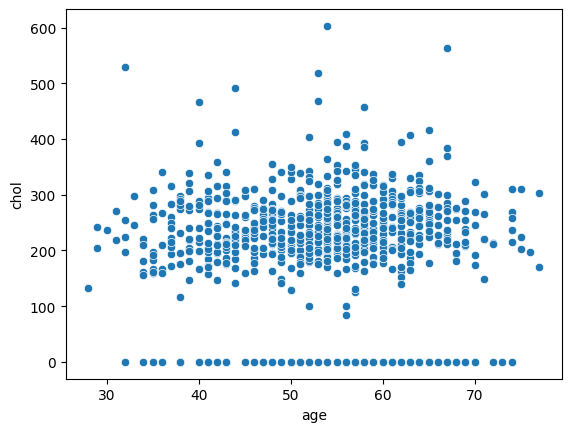

In [92]:
sns.scatterplot(x="age", y="chol", data=df)

<Axes: xlabel='country', ylabel='chol'>

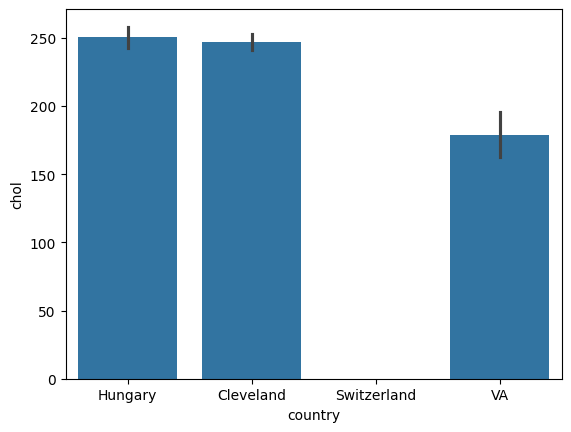

In [93]:
sns.barplot(x="country", y="chol", data=df)

<Axes: xlabel='country', ylabel='chol'>

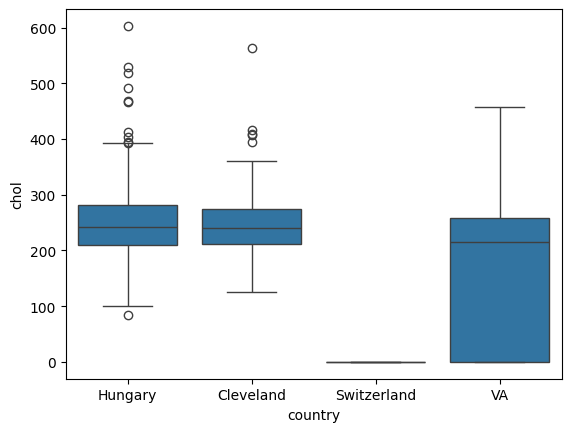

In [94]:
sns.boxplot(x="country", y="chol", data=df)

In [95]:
average_target = df.groupby("country")["target"].mean().reset_index()
average_target

,country,target
0,Cleveland,0.448845
1,Hungary,0.380952
2,Switzerland,0.861789
3,VA,0.740000


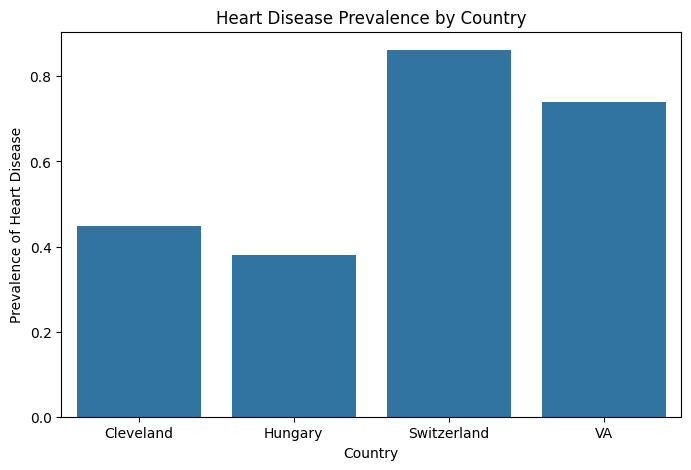

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))
sns.barplot(x = "country", y = "target", data= average_target)
plt.title("Heart Disease Prevalence by Country")
plt.ylabel("Prevalence of Heart Disease")
plt.xlabel("Country")
plt.show()

<Axes: xlabel='chol', ylabel='Count'>

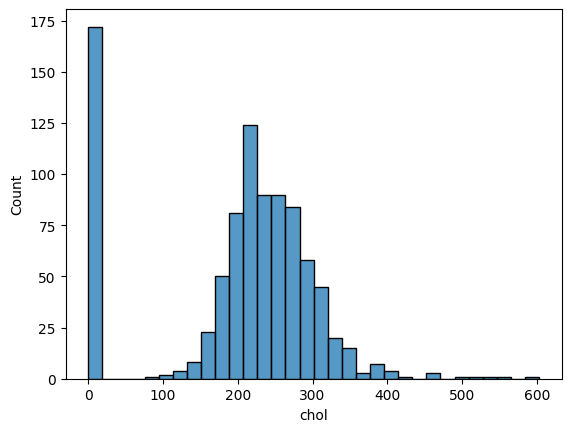

In [97]:
sns.histplot(df["chol"])

In [98]:
(df["chol"] == 0).sum()

np.int64(172)

A substantial number of zero values were observed in the cholesterol variable, suggesting the presence of hidden missing values or inconsistent recording practices.

In [99]:
df[df["chol"] == 0]["country"].value_counts()

country
Switzerland    123
VA              49
Name: count, dtype: int64

<Axes: xlabel='trestbps', ylabel='Count'>

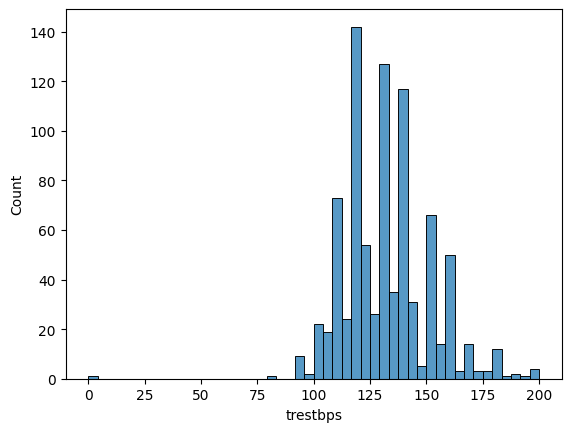

In [100]:
sns.histplot(df["trestbps"])

In [101]:
(df["trestbps"] == 0).sum()

np.int64(1)

In [102]:
df[df["trestbps"] == 0]["country"].value_counts()

country
VA    1
Name: count, dtype: int64

<Axes: xlabel='oldpeak', ylabel='Count'>

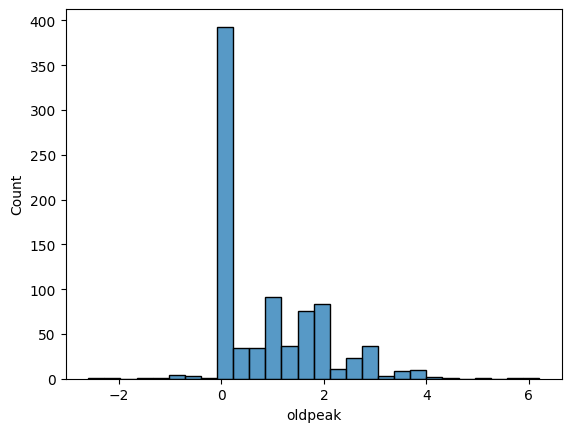

In [103]:
sns.histplot(df["oldpeak"])

In [104]:
(df["oldpeak"] < 0).sum()

np.int64(12)

In [105]:
df[df["oldpeak"] < 0]["country"].value_counts()

country
Switzerland    11
VA              1
Name: count, dtype: int64

## Data Quality Observations

- The cholesterol variable contains many zero values, especially in the Switzerland subset, suggesting hidden missing values.

- The trestbps variable contains only one zero value, likely representing an isolated recording issue.

- A small number of negative oldpeak values were observed, mainly in Switzerland. These may reflect measurement or recording differences.

- Several variables appear to differ across regions, indicating that the populations may not be fully homogeneous.

<Axes: xlabel='country', ylabel='chol'>

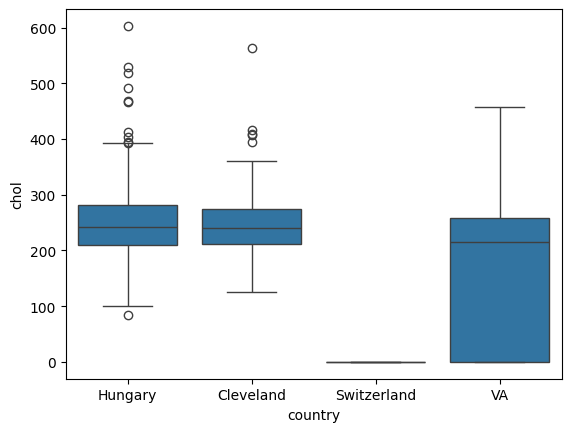

In [106]:
sns.boxplot(data=df, x="country", y= "chol")

<Axes: xlabel='thalach', ylabel='Count'>

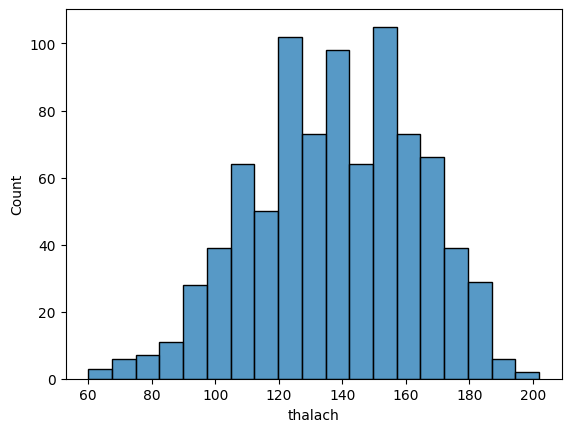

In [107]:
sns.histplot(df["thalach"])

In [108]:
df["thalach"].describe()

count    865.000000
mean     137.545665
std       25.926276
min       60.000000
25%      120.000000
50%      140.000000
75%      157.000000
max      202.000000
Name: thalach, dtype: float64

<Axes: xlabel='country', ylabel='thalach'>

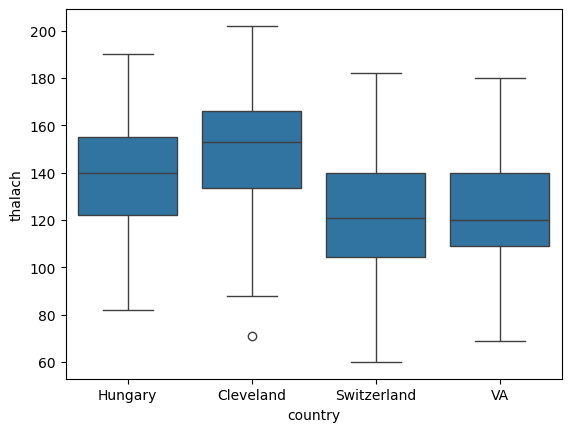

In [109]:
sns.boxplot(data=df, x="country", y="thalach")

<Axes: xlabel='age', ylabel='Count'>

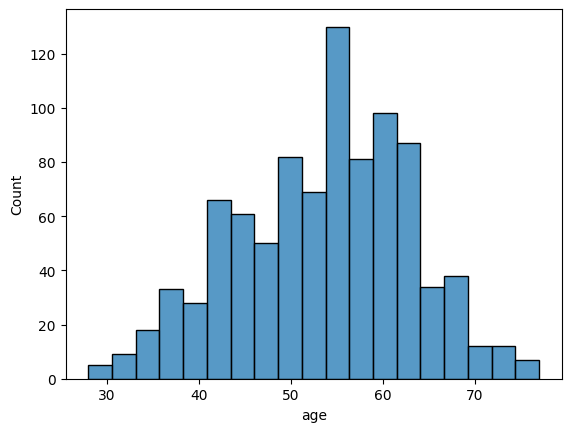

In [110]:
sns.histplot(df["age"])

In [111]:
df["age"].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

<Axes: xlabel='country', ylabel='age'>

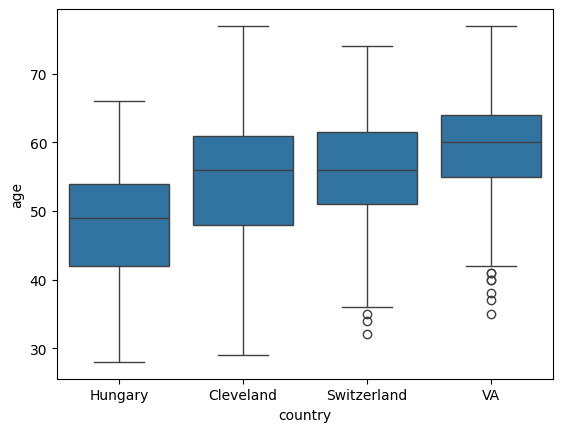

In [112]:
sns.boxplot(data=df, x="country", y="age")

## Initial Findings from Key Numerical Variables

### Cholesterol (`chol`)
- The cholesterol variable contains a large number of zero values, especially in the Switzerland and VA subsets.
- Since a cholesterol value of 0 is clinically unrealistic, these values likely represent hidden missing values or inconsistent recording practices.
- Hungary and Cleveland show several high cholesterol outliers, but these values appear medically plausible.

### Maximum Heart Rate (`thalach`)
- The thalach variable appears relatively clean and normally distributed.
- Only standard outliers were observed, with no obvious data quality issues.
- Cleveland patients tend to have slightly higher maximum heart rates, while Switzerland and VA show lower median values.

### Age (`age`)
- The age variable appears consistent and realistic across all regions.
- No suspicious or impossible values were observed.
- Patients from VA and Switzerland appear older on average compared to Hungary.
- Since age is an important cardiovascular risk factor, these regional age differences may partially explain differences in heart disease prevalence.

In [113]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,-0.690000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.0,0.0,4.0,127.0,333.0,1.0,1.0,154.0,0.0,0.0,NaN,NaN,NaN,1,2.120000
916,62.0,1.0,1.0,NaN,139.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
917,55.0,1.0,4.0,122.0,223.0,1.0,1.0,100.0,0.0,0.0,NaN,NaN,6.0,1,2.110000
918,58.0,1.0,4.0,NaN,385.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [114]:
corr = numeric_df.corr()
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,clinical_index
age,1.000000,0.056889,0.166245,0.244253,-0.086234,0.233726,0.212719,-0.365778,0.201626,0.258243,0.155032,0.370416,0.137298,0.236284,0.213014
sex,0.056889,1.000000,0.170392,0.001087,-0.197281,0.089191,-0.015612,-0.179320,0.181420,0.103930,0.125154,0.094123,0.373927,0.266809,-0.110854
cp,0.166245,0.170392,1.000000,0.025075,-0.132576,0.039838,0.031101,-0.349189,0.419384,0.244245,0.202989,0.214975,0.313150,0.343715,0.044648
trestbps,0.244253,0.001087,0.025075,1.000000,0.092853,0.160235,0.098857,-0.104899,0.152328,0.161908,0.063387,0.093705,0.107555,0.080161,0.168989
chol,-0.086234,-0.197281,-0.132576,0.092853,1.000000,0.024847,0.116494,0.236121,-0.034557,0.047734,-0.059276,0.051606,-0.179903,-0.213026,0.863320
fbs,0.233726,0.089191,0.039838,0.160235,0.024847,1.000000,0.132347,-0.053386,0.029176,0.055277,0.092142,0.149539,0.105871,0.119849,0.077823
restecg,0.212719,-0.015612,0.031101,0.098857,0.116494,0.132347,1.000000,0.053120,0.032331,0.118297,-0.014771,0.139154,-0.040084,0.034526,0.121062
thalach,-0.365778,-0.179320,-0.349189,-0.104899,0.236121,-0.053386,0.053120,1.000000,-0.356439,-0.151174,-0.360622,-0.264094,-0.327360,-0.315088,-0.283088
exang,0.201626,0.181420,0.419384,0.152328,-0.034557,0.029176,0.032331,-0.356439,1.000000,0.392492,0.319424,0.127385,0.340737,0.342746,0.157824
oldpeak,0.258243,0.103930,0.244245,0.161908,0.047734,0.055277,0.118297,-0.151174,0.392492,1.000000,0.421184,0.281817,0.254391,0.320702,0.147710


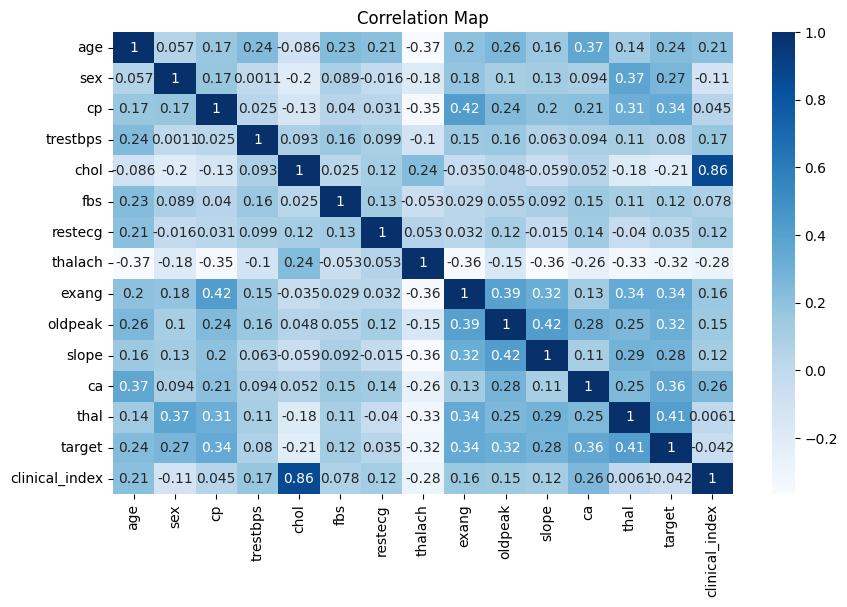

In [115]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Map")
plt.show()

## Correlation Analysis Findings

- `thal`, `ca`, `cp`, and `oldpeak` show moderate positive correlations with heart disease.

- `thalach` shows a moderate negative correlation with the target, suggesting that lower maximum heart rate may be associated with higher disease risk.

- Cholesterol exhibits only a weak correlation with the target, possibly due to hidden missing values and inconsistencies across regions.

- The `clinical_index` variable is strongly correlated with cholesterol, indicating potential multicollinearity if both are included in the same predictive model.

## Overall Initial Insights

- The dataset contains several missing values and region-specific inconsistencies.
- The cholesterol variable appears particularly problematic due to many zero values, mainly in the Switzerland subset.
- Some variables, such as age and thalach, appear relatively clean and well-behaved.
- Disease prevalence differs substantially across regions, suggesting that the populations may not be fully homogeneous.
- Correlation analysis indicates that variables such as thal, ca, exang, oldpeak, and thalach may play important roles in predicting heart disease.
- Strong correlations involving the clinical_index variable suggest possible multicollinearity issues in future modeling.